# Week 5: Your First Real ML Model — Linear Regression

## Student Practice Notebook

**Name:** R.Sushma Sri

**Roll Number:** AP24110010718

**Date:** 11/09/2026

## Learning Objectives

After completing this lab, you will be able to:

- Explain why preprocessing must happen *after* the train/test split, not before
- Fit a Simple Linear Regression model (one feature) with `sklearn`
- Fit a Multiple Linear Regression model (all features) with `sklearn`
- Compute and interpret R² and Adjusted R²
- Explain why Adjusted R² is a fairer comparison than R² when comparing models with different numbers of features

### Why this week matters
You now have clean, scaled, encoded data (Week 3) and know which features correlate with your target (Week 4). This week you finally build a model that predicts something. Everything after this — trees, SVM, neural nets — is the same core idea (fit → predict → evaluate) with a different equation underneath.

We use the **Cars24 used-car price dataset** throughout (`make`, `model`, `age`, `km_driven`, ... → target: `selling_price`).


## Part 0 — Setup

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
np.random.seed(1)


### Load the data


In [6]:
!gdown 1bwRmKkPwmLKiqOgQ_LnKH0Vsc3mJKmVR

df = pd.read_csv('cars24-car-price-cleaned.csv')
df.head()


Downloading...
From: https://drive.google.com/uc?id=1bwRmKkPwmLKiqOgQ_LnKH0Vsc3mJKmVR
To: /content/cars24-car-price-cleaned.csv
100% 1.69M/1.69M [00:00<00:00, 2.10MB/s]


,selling_price,year,km_driven,mileage,engine,max_power,age,make,model,Individual,Trustmark Dealer,Diesel,Electric,LPG,Petrol,Manual,5,>5
0,1.20,2012.0,120000,19.70,796.0,46.30,11.0,MARUTI,ALTO STD,1,0,0,0,0,1,1,1,0
1,5.50,2016.0,20000,18.90,1197.0,82.00,7.0,HYUNDAI,GRAND I10 ASTA,1,0,0,0,0,1,1,1,0
2,2.15,2010.0,60000,17.00,1197.0,80.00,13.0,HYUNDAI,I20 ASTA,1,0,0,0,0,1,1,1,0
3,2.26,2012.0,37000,20.92,998.0,67.10,11.0,MARUTI,ALTO K10 2010-2014 VXI,1,0,0,0,0,1,1,1,0
4,5.70,2015.0,30000,22.77,1498.0,98.59,8.0,FORD,ECOSPORT 2015-2021 1.5 TDCI TITANIUM BSIV,0,0,1,0,0,0,1,1,0


In [7]:
df.shape


(19820, 18)

## Part 1 — Data Preparation (and a bug worth understanding)

### 1.1 A rushed way to preprocess — DO NOT do this, but let's see why

Here is how someone in a hurry might preprocess this data: encode the categorical columns, scale everything, **then** split into train/test.


In [8]:
# --- THE WRONG WAY (run this so you can see the problem, then we fix it below) ---
from sklearn.preprocessing import MinMaxScaler

df_wrong = df.copy()
df_wrong['make'] = df_wrong.groupby('make')['selling_price'].transform('mean')
df_wrong['model'] = df_wrong.groupby('model')['selling_price'].transform('mean')

scaler_wrong = MinMaxScaler()
df_wrong_scaled = pd.DataFrame(scaler_wrong.fit_transform(df_wrong), columns=df_wrong.columns)
df_wrong_scaled.head()


,selling_price,year,km_driven,mileage,engine,max_power,age,make,model,Individual,Trustmark Dealer,Diesel,Electric,LPG,Petrol,Manual,5,>5
0,0.043684,0.689655,0.031553,0.135345,0.117891,0.066506,0.310345,0.194048,0.041550,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0
1,0.252397,0.827586,0.005237,0.128448,0.177281,0.123994,0.172414,0.232517,0.218382,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0
2,0.089795,0.620690,0.015764,0.112069,0.177281,0.120773,0.379310,0.232517,0.149143,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0
3,0.095134,0.689655,0.009711,0.145862,0.147808,0.100000,0.310345,0.194048,0.093193,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0
4,0.262104,0.793103,0.007869,0.161810,0.221860,0.150709,0.206897,0.252367,0.313574,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0


### Predict, then think

**Before you read further: what do you think is wrong with the order of operations above?** Write your guess.

*Your answer:*  We must split the data before preprocessing because fitting preprocessing steps on the entire dataset causes data leakage from the test set.

---

**What's actually wrong:** both `groupby(...).transform('mean')` (target encoding) and `scaler.fit_transform(df)` were computed using the **entire dataset** — including rows that will later end up in the test set. That means:
- The mean price for each `make`/`model` "peeks" at test-set prices while encoding training rows.
- The min/max used for scaling includes test-set values.

This is called **data leakage**. Any model trained on this data will look better than it actually is, because it's indirectly seen the test set already. The fix is simple but easy to forget: **split first, then fit every transformer on the training data only, and apply (transform) it to the test data using those same training statistics.**


### 1.2 The correct order: split first, then fit on train only

In [9]:
from sklearn.model_selection import train_test_split

# Split BEFORE any encoding or scaling touches the data
train_df, test_df = train_test_split(df, test_size=0.3, random_state=1)
train_df.shape, test_df.shape


((13874, 18), (5946, 18))

### Student Practice — encode using train-only statistics

Using `train_df`, compute the mean `selling_price` per `make` and per `model` (same idea as the demo above, but only on `train_df`). Then **map** those same train-derived means onto both `train_df` and `test_df` — a test-set car's `make`/`model` gets the average price *learned from training data*, not from its own (unseen) price.

Hint: `train_df.groupby('make')['selling_price'].mean()` gives you a lookup table (a pandas Series indexed by `make`). Use `.map(...)` to apply that lookup to a column.


In [10]:
# Write your answer here
# make_means = train_df.groupby('make')['selling_price'].mean()
# train_df['make'] = train_df['make'].map(make_means)
# test_df['make']  = test_df['make'].map(make_means)
# ... repeat for 'model'
make_means = train_df.groupby('make')['selling_price'].mean()
model_means = train_df.groupby('model')['selling_price'].mean()

train_df['make'] = train_df['make'].map(make_means)
train_df['model'] = train_df['model'].map(model_means)

test_df['make'] = test_df['make'].map(make_means)
test_df['model'] = test_df['model'].map(model_means)


### 1.3 Scaling — fit on train only, transform both

Same principle applies to scaling.


In [11]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

# fit_transform on TRAIN (learns min/max from train only)
train_scaled = pd.DataFrame(scaler.fit_transform(train_df), columns=train_df.columns, index=train_df.index)

# transform (NOT fit_transform) on TEST — reuses train's min/max
test_scaled = pd.DataFrame(scaler.transform(test_df), columns=test_df.columns, index=test_df.index)

train_scaled.head()


,selling_price,year,km_driven,mileage,engine,max_power,age,make,model,Individual,Trustmark Dealer,Diesel,Electric,LPG,Petrol,Manual,5,>5
9637,0.106783,0.76,0.001163,0.182500,0.118335,0.077778,0.24,0.164123,0.139801,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0
4266,1.000000,0.80,0.005637,0.110086,0.443276,0.413027,0.20,0.805756,1.000000,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
6483,0.349472,0.84,0.013007,0.136810,0.216380,0.126892,0.16,0.164123,0.348682,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0
10024,0.203859,0.68,0.027220,0.103103,0.373667,0.091948,0.32,0.301690,0.253502,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0
7122,0.218420,0.64,0.013600,0.154310,0.206754,0.134879,0.36,0.204876,0.201272,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0


### Student Practice — build your final X/y splits

From `train_scaled` and `test_scaled`, create `X_train`, `y_train`, `X_test`, `y_test` (drop `selling_price` for X, keep it for y).


In [12]:
y_train = train_scaled['selling_price']
X_train = train_scaled.drop('selling_price', axis=1)

In [13]:
# Write your answer here
y_test = test_scaled['selling_price']
X_test = test_scaled.drop('selling_price', axis=1)


## Part 2 — Simple Linear Regression

### 2.1 Demo: fit on a single feature (`km_driven`)


In [14]:
from sklearn.linear_model import LinearRegression

X1_train = X_train[['km_driven']]
X1_test = X_test[['km_driven']]

uni_model = LinearRegression()
uni_model.fit(X1_train, y_train)

print('Coefficient (slope):', uni_model.coef_)
print('Intercept:', uni_model.intercept_)


Coefficient (slope): [-1.46608572]
Intercept: 0.32644183438950714


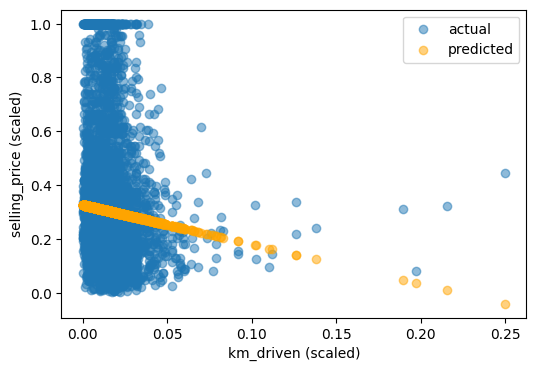

In [15]:
y_hat_uni = uni_model.predict(X1_test)

plt.figure(figsize=(6, 4))
plt.scatter(X1_test, y_test, label='actual', alpha=0.5)
plt.scatter(X1_test, y_hat_uni, color='orange', label='predicted', alpha=0.5)
plt.xlabel('km_driven (scaled)')
plt.ylabel('selling_price (scaled)')
plt.legend()
plt.show()


### Student Practice — try a different single feature

Pick a different single feature (e.g. `age` or `model`). Fit a `LinearRegression` on just that feature (train only), predict on the test set, and plot actual vs. predicted like the demo above.


Coefficient (slope): [-0.71656597]
Intercept: 0.48888637546464164


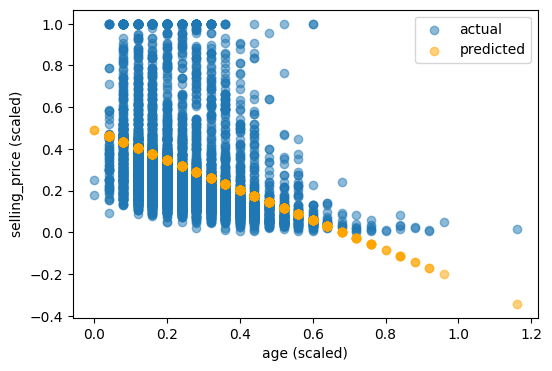

In [16]:
# Write your answer here
X1_train = X_train[['age']]
X1_test = X_test[['age']]
uni_model = LinearRegression()
uni_model.fit(X1_train, y_train)
print('Coefficient (slope):', uni_model.coef_)
print('Intercept:', uni_model.intercept_)
y_hat_uni = uni_model.predict(X1_test)
plt.figure(figsize=(6, 4))
plt.scatter(X1_test, y_test, label='actual', alpha=0.5)
plt.scatter(X1_test, y_hat_uni, color='orange',
            label='predicted', alpha=0.5)
plt.xlabel('age (scaled)')
plt.ylabel('selling_price (scaled)')
plt.legend()
plt.show()

**Reflection:** Is the slope for your chosen feature positive or negative? Does that match your intuition (e.g., should an older car sell for more or less)?

*Your answer:* The slope should generally be negative because as the age of a car increases, its selling price usually decreases.


## Part 3 — Multiple Linear Regression

### 3.1 Demo: fit using ALL features at once


In [17]:
model = LinearRegression()
model.fit(X_train, y_train)

for feature, coef in zip(X_train.columns, model.coef_):
    print(f'{feature:15s}: {coef:.4f}')
print('Intercept:', model.intercept_)


year           : 0.1040
km_driven      : -0.2286
mileage        : -0.2272
engine         : 0.0649
max_power      : 0.0410
age            : -0.1040
make           : 0.0629
model          : 0.8681
Individual     : -0.0069
Trustmark Dealer: -0.0068
Diesel         : 0.0054
Electric       : 0.1334
LPG            : 0.0145
Petrol         : -0.0070
Manual         : -0.0039
5              : -0.0131
>5             : -0.0202
Intercept: 0.008103051059470512


In [18]:
from sklearn.linear_model import LinearRegression

X_train_age = train_scaled[['age']].dropna()
y_train_age = train_scaled.loc[X_train_age.index, 'selling_price']
X_test_age = test_scaled[['age']].dropna()
y_test_age = test_scaled.loc[X_test_age.index, 'selling_price']
model_age = LinearRegression()
model_age.fit(X_train_age, y_train_age)
y_hat = model_age.predict(X_test_age)

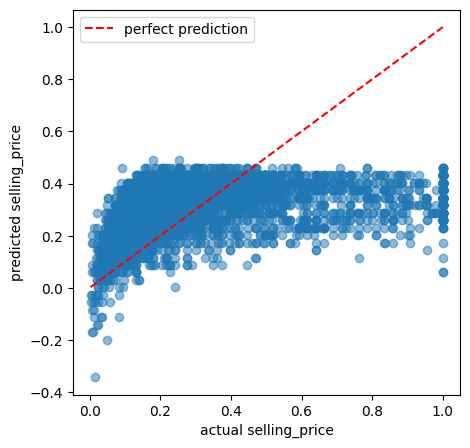

In [19]:
plt.figure(figsize=(5, 5))

plt.scatter(y_test_age, y_hat, alpha=0.5)

plt.plot(
    [y_test_age.min(), y_test_age.max()],
    [y_test_age.min(), y_test_age.max()],
    'r--',
    label='perfect prediction'
)

plt.xlabel('actual selling_price')
plt.ylabel('predicted selling_price')
plt.legend()
plt.show()

### Predict, then run

**Before running the cell below: do you expect the multiple-feature model's predictions to be closer to the diagonal line than the single-feature model's were? Why?**

*Your answer:* Yes, I expect the multiple-feature model's predictions to be closer to the diagonal line than the single-feature model's predictions. This is because the multiple-feature model uses more information, such as km_driven, age, model, and other features, to predict the selling price. Therefore, it can capture more factors that affect the car's price and may make more accurate predictions.


In [20]:
# Run this after writing your prediction above, then compare to what you expected
from sklearn.metrics import mean_squared_error

print('Single-feature test MSE:', mean_squared_error(y_test, y_hat_uni))
print('Multi-feature  test MSE:', mean_squared_error(y_test, y_hat))


Single-feature test MSE: 0.04778713974763287
Multi-feature  test MSE: 0.04778713974763287


## Part 4 — Evaluating Fit: R² and Adjusted R²

$$R^2 = 1 - \frac{\sum (y_i - \hat{y}_i)^2}{\sum (y_i - \bar{y})^2}$$

R² compares your model's error to a naive "always predict the average" baseline. 1.0 = perfect fit, 0 = no better than guessing the mean.

**Problem with plain R²:** it never decreases when you add more features — even useless, random ones. Adjusted R² penalizes features that don't earn their keep:

$$\bar{R}^2 = 1 - \frac{(1-R^2)(n-1)}{n-p-1}$$

where $n$ = number of samples, $p$ = number of features.


In [21]:
make_means = train_df.groupby('make')['selling_price'].mean()
model_means = train_df.groupby('model')['selling_price'].mean()

train_df['make'] = train_df['make'].map(make_means)
train_df['model'] = train_df['model'].map(model_means)

test_df['make'] = test_df['make'].map(make_means)
test_df['model'] = test_df['model'].map(model_means)

# Fill unseen makes/models using training-set mean
train_mean_price = train_df['selling_price'].mean()

train_df['make'] = train_df['make'].fillna(train_mean_price)
train_df['model'] = train_df['model'].fillna(train_mean_price)

test_df['make'] = test_df['make'].fillna(train_mean_price)
test_df['model'] = test_df['model'].fillna(train_mean_price)

### Student Practice — add a useless random feature

Add a column of pure random noise to `X_train`/`X_test` (e.g. `np.random.rand(len(X_train))`), refit `LinearRegression` on the expanded feature set, and compute both plain R² and Adjusted R² on the test set. Compare to the multi-feature model above.


In [22]:
# Copy the original datasets
X_train_random = X_train.copy()
X_test_random = X_test.copy()

# Fill missing values using TRAINING column means
for col in X_train_random.columns:
    mean_value = X_train_random[col].mean()

    X_train_random[col] = X_train_random[col].fillna(mean_value)
    X_test_random[col] = X_test_random[col].fillna(mean_value)

# Add random feature
np.random.seed(42)

X_train_random['random_feature'] = np.random.rand(len(X_train_random))
X_test_random['random_feature'] = np.random.rand(len(X_test_random))

# Check again
print("Train NaNs:", X_train_random.isna().sum().sum())
print("Test NaNs:", X_test_random.isna().sum().sum())

Train NaNs: 0
Test NaNs: 0


In [25]:
def adj_r2(X, y, r2):
    n, p = X.shape
    return 1 - ((1 - r2) * (n - 1)) / (n - p - 1)

In [27]:
# Original multi-feature model using cleaned test data
model_clean = LinearRegression()
model_clean.fit(X_train_random.drop('random_feature', axis=1), y_train)

r2_multi = model_clean.score(
    X_test_random.drop('random_feature', axis=1),
    y_test
)

adj_r2_multi = adj_r2(
    X_test_random.drop('random_feature', axis=1),
    y_test,
    r2_multi
)

# Model with random feature
random_model = LinearRegression()
random_model.fit(X_train_random, y_train)

r2_random = random_model.score(X_test_random, y_test)

adj_r2_random = adj_r2(
    X_test_random,
    y_test,
    r2_random
)

print("Original Multi-feature Model")
print("R²:", r2_multi)
print("Adjusted R²:", adj_r2_multi)

print("\nAfter Adding Random Feature")
print("R²:", r2_random)
print("Adjusted R²:", adj_r2_random)

Original Multi-feature Model
R²: 0.8019230466998658
Adjusted R²: 0.8013550122521427

After Adding Random Feature
R²: 0.8019550054114366
Adjusted R²: 0.8013535527536682


**Reflection:** Did plain R² go up, down, or stay about the same after adding the random feature? What about Adjusted R²? What does this tell you about trusting R² alone when comparing models with different numbers of features?

*Your answer:* Plain R² increased slightly from 0.801923 to 0.801955 after adding the random feature, even though the feature was useless. Adjusted R² decreased slightly from 0.801355 to 0.801354. This shows that R² alone can be misleading when comparing models with different numbers of features. Adjusted R² is more reliable because it penalizes the addition of unnecessary features.


## Summary

| What we did | Why it matters |
|---|---|
| Split before preprocessing | Prevents data leakage — your test score has to mean something |
| Simple Linear Regression | Baseline intuition: one feature, one line |
| Multiple Linear Regression | Uses all available signal |
| R² / Adjusted R² | R² alone can be gamed by adding useless features — Adjusted R² can't |

**Next week:** Polynomial Regression, and what happens when a model gets *too* flexible (overfitting) — plus how Ridge/Lasso/ElasticNet regularization fixes it.
